In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
# ---------------------------------------------
# STEP 1 — Mount Drive & Import
# ---------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ---------------------------------------------
# STEP 2 — Dataset Path & Data Augmentation
# ---------------------------------------------
data_dir = "/content/drive/MyDrive/Garbage classification"
img_size = (128,128)
batch_size = 32

aug_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = aug_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = aug_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [6]:
# ---------------------------------------------
# STEP 3 — Load & Partially Unfreeze VGG16
# ---------------------------------------------
base_model = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(128,128,3))

# Unfreeze top layers (fine-tune last 4 conv blocks)
for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# ---------------------------------------------
# STEP 4 — Add Custom Layers
# ---------------------------------------------
model4 = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

model4.compile(optimizer=Adam(learning_rate=0.00005),
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,912,582 (72.15 MB)

 Trainable params: 11,277,318 (43.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [8]:
# ---------------------------------------------
# STEP 5 — Train Model
# ---------------------------------------------
history4 = model4.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 606s 9s/step - accuracy: 0.2785 - loss: 1.7416 - val_accuracy: 0.5586 - val_loss: 1.0993
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 540s 8s/step - accuracy: 0.6079 - loss: 1.0187 - val_accuracy: 0.6143 - val_loss: 1.0119
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 540s 8s/step - accuracy: 0.6864 - loss: 0.8270 - val_accuracy: 0.6282 - val_loss: 0.9857
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 539s 8s/step - accuracy: 0.7238 - loss: 0.7136 - val_accuracy: 0.6640 - val_loss: 0.9220
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 539s 8s/step - accuracy: 0.7741 - loss: 0.5956 - val_accuracy: 0.6759 - val_loss: 0.8649
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 541s 8s/step - accuracy: 0.7924 - loss: 0.5793 - val_accuracy: 0.6859 - val_loss: 0.8951
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 586s 9s/step - accuracy: 0.8143 - loss: 0.5441 - val_accuracy: 0.6799 - val_loss: 0.8312
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 536s 8s/step - accuracy: 0.8501 - loss: 0.4325 - val_accuracy: 0.7137 - v

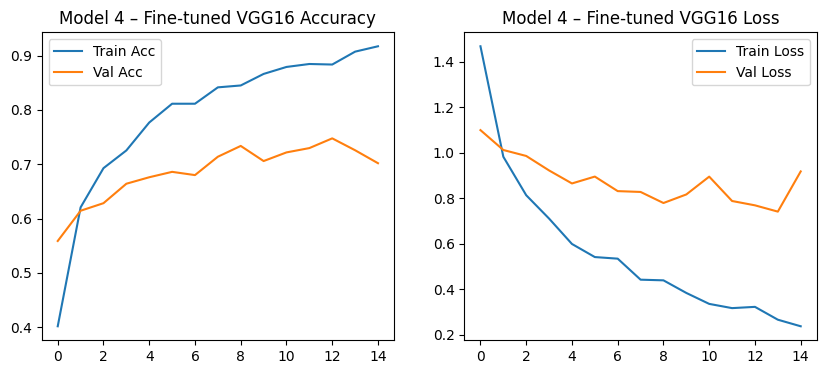

In [9]:
 # ---------------------------------------------
# STEP 6 — Plot Results
# ---------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history4.history['accuracy'], label='Train Acc')
plt.plot(history4.history['val_accuracy'], label='Val Acc')
plt.title('Model 4 – Fine-tuned VGG16 Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history4.history['loss'], label='Train Loss')
plt.plot(history4.history['val_loss'], label='Val Loss')
plt.title('Model 4 – Fine-tuned VGG16 Loss'); plt.legend()
plt.show()

In [10]:
# ---------------------------------------------
# STEP 7 — Evaluate & Save Results
# ---------------------------------------------
val_loss, val_acc = model4.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

results_dir = "/content/drive/MyDrive/Waste_Classification_Project/results"
os.makedirs(results_dir, exist_ok=True)

model4.save(os.path.join(results_dir, "model4_vgg16_finetuned.h5"))
plt.savefig(os.path.join(results_dir, "model4_vgg16_finetuned_training_plot.png"))


16/16 ━━━━━━━━━━━━━━━━━━━━ 92s 6s/step - accuracy: 0.7152 - loss: 0.7902


Validation Accuracy: 70.18%
Validation Loss: 0.8556


<Figure size 640x480 with 0 Axes>